当前运行的 Python 路径: d:\miniconda\python.exe
Using device: cuda
正在将海量数据载入内存，请耐心等待...
载入完成！Train samples: 85472 | Val samples: 5862
正在自动计算最优类别平衡权重...

🚀 开始终极训练 (Seq2Seq 上下文 + 物理增强 + 平滑交叉熵) ...
Epoch [01/40] | Train Loss: 1.1294 | Val Loss: 1.0762 | Val Acc: 0.6733 | Val Macro-F1: 0.6565 | LR: 0.000200
   => [Checkpoint] 模型拥有了时序记忆，已保存至 'best_sleep_model_seq2seq.pth'
Epoch [02/40] | Train Loss: 0.9760 | Val Loss: 1.0811 | Val Acc: 0.6486 | Val Macro-F1: 0.6229 | LR: 0.000195
Epoch [03/40] | Train Loss: 0.9430 | Val Loss: 1.0693 | Val Acc: 0.6905 | Val Macro-F1: 0.6625 | LR: 0.000181
   => [Checkpoint] 模型拥有了时序记忆，已保存至 'best_sleep_model_seq2seq.pth'
Epoch [04/40] | Train Loss: 0.9195 | Val Loss: 0.9722 | Val Acc: 0.7139 | Val Macro-F1: 0.7115 | LR: 0.000159
   => [Checkpoint] 模型拥有了时序记忆，已保存至 'best_sleep_model_seq2seq.pth'
Epoch [05/40] | Train Loss: 0.9018 | Val Loss: 0.9812 | Val Acc: 0.6875 | Val Macro-F1: 0.6957 | LR: 0.000131
Epoch [06/40] | Train Loss: 0.8854 | Val Loss: 0.9319 | Val Acc: 0.

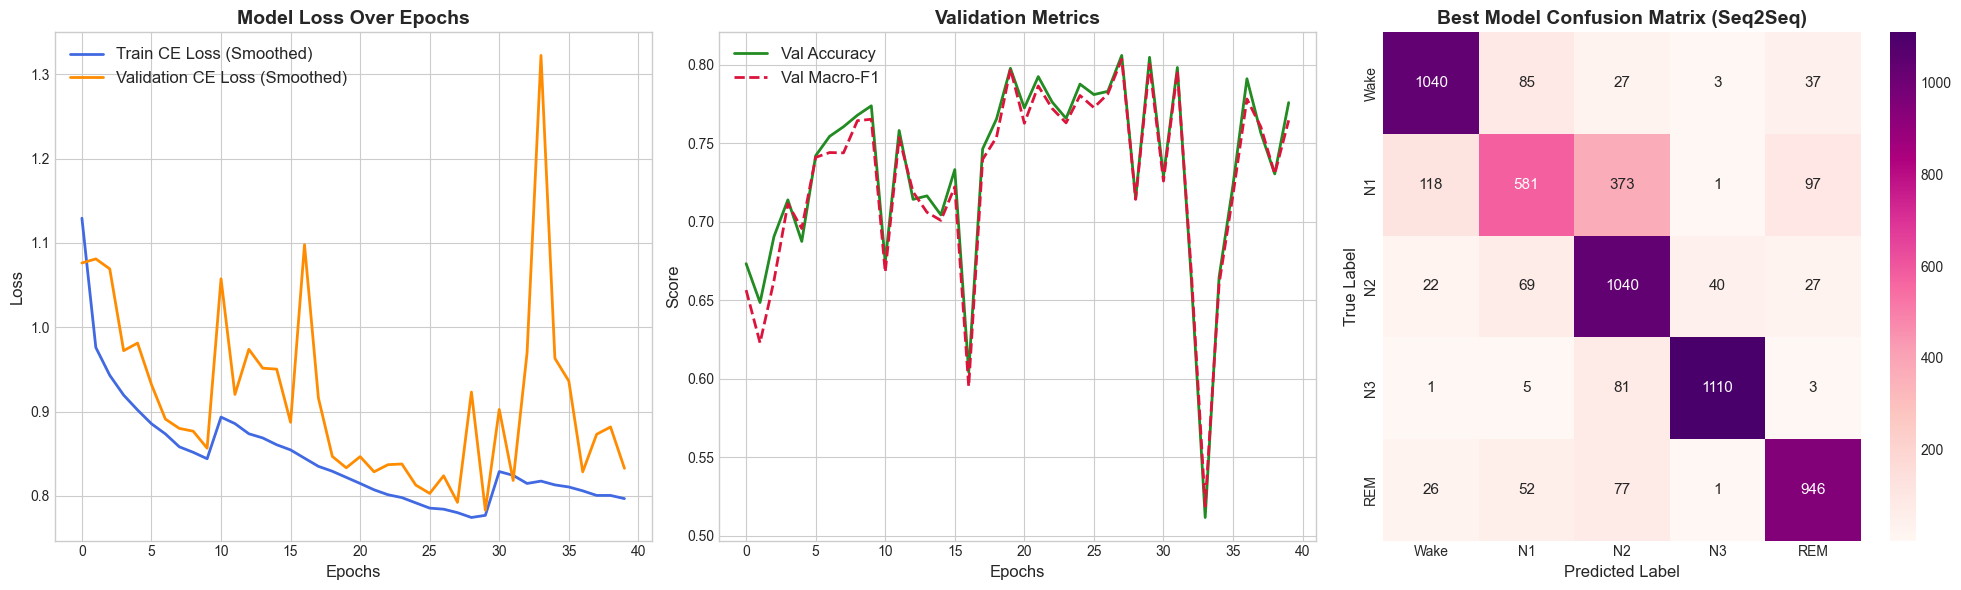

✅ 终极训练报告图表已保存为 'training_report_seq2seq.png'


In [ ]:
import sys
print("当前运行的 Python 路径:", sys.executable)
import os
# 强行把 PyTorch 自己的 lib 目录和 Python 的底层库目录塞给系统
os.add_dll_directory(r"C:\Users\18237\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\lib")

import random
from pathlib import Path

import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 0. 全局配置与硬件加速
# ============================================================
torch.backends.cudnn.benchmark = True

# 由于引入 Seq2Seq，显存消耗增加约 5 倍，Batch Size 安全回调至 64
BATCH_SIZE = 64 
EPOCHS = 40        
LR = 2e-4
WEIGHT_DECAY = 1e-4
SEED = 42
SEQ_LEN = 5  # 宏观时间序列窗口大小：前2个 + 中心1个 + 后2个

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ============================================================
# 1. 重构数据加载器：Seq2Seq 滑动窗口与边缘复制填充
# ============================================================
class SleepSeqDatasetInMemory(Dataset):
    def __init__(self, h5_path, seq_len=5):
        """带有滑动窗口机制的睡眠数据集 (Seq2Seq Many-to-One)"""
        super().__init__()
        assert seq_len % 2 == 1, "seq_len 必须为奇数，以确保存在明确的中心 Epoch！"
        
        self.h5_path = str(h5_path)
        self.seq_len = seq_len
        self.pad_size = seq_len // 2  
        
        # 1. 一次性载入病人的整夜数据
        with h5py.File(self.h5_path, "r") as f:
            # raw_X 形状: [N, Channels, Time]
            raw_X = torch.tensor(f["X"][:], dtype=torch.float32)
            self.y = torch.tensor(f["y"][:], dtype=torch.long)
            
        self.num_samples = len(self.y)
        
        # 2. 处理边缘填充 (Edge Replication Padding)
        if self.num_samples > 0:
            pad_front = raw_X[0:1].repeat(self.pad_size, 1, 1)  # 复制第 1 个 Epoch
            pad_back  = raw_X[-1:].repeat(self.pad_size, 1, 1)  # 复制最后一个 Epoch
            # 拼接后形状变更为: [N + 2*pad_size, Channels, Time]
            self.X_padded = torch.cat([pad_front, raw_X, pad_back], dim=0)
        else:
            self.X_padded = raw_X

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 3. 滑动窗口截取
        # 截取范围刚好包含 pad_size 前置 + 中心 + pad_size 后置
        X_seq = self.X_padded[idx : idx + self.seq_len]  
        # X_seq 形状: [seq_len=5, Channels=6, Time=3000]
        
        # 标签严格对应这个序列的“中心 Epoch”
        y_center = self.y[idx]
        
        return X_seq, y_center

def load_split_files(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        paths = [Path(line.strip()) for line in f if line.strip()]
    return paths

# ============================================================
# 2. 核心模块：一维通道注意力机制 (1D SE-Block)
# ============================================================
class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        channel_weights = self.fc(x).view(b, c, 1)
        return x * channel_weights

# ============================================================
# 3. 升维网络：TimeDistributed CNN + 宏观状态转移 LSTM
# ============================================================
# ============================================================
# 3. 升维网络：TimeDistributed CNN + 宏观状态转移 LSTM
# ============================================================
class MultiScaleCNNWithAttention(nn.Module):
    def __init__(self, in_chans, out_chans=64):
        super().__init__()
        # 针对 200Hz 数据 (6000采样点) 的专属感受野放大版
        
        # Branch 1: 捕捉极高频特征 (如纺锤波/肌电高频)
        # 原 100Hz: k=7, s=4, p=3 -> 新 200Hz: k=15, s=8, p=7 (物理窗口约 0.075s)
        self.branch1 = nn.Sequential(
            nn.Conv1d(in_chans, 16, kernel_size=15, stride=8, padding=7),
            nn.BatchNorm1d(16),
            nn.ReLU()
        )
        
        # Branch 2: 捕捉中频特征 (如 Alpha/Theta 波)
        # 原 100Hz: k=31, s=4, p=15 -> 新 200Hz: k=63, s=8, p=31 (物理窗口约 0.315s)
        self.branch2 = nn.Sequential(
            nn.Conv1d(in_chans, 24, kernel_size=63, stride=8, padding=31),
            nn.BatchNorm1d(24),
            nn.ReLU()
        )
        
        # Branch 3: 捕捉超低频慢波特征 (如深睡 Delta 波/K复合波)
        # 原 100Hz: k=63, s=4, p=31 -> 新 200Hz: k=127, s=8, p=63 (物理窗口约 0.635s)
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_chans, 24, kernel_size=127, stride=8, padding=63),
            nn.BatchNorm1d(24),
            nn.ReLU()
        )
        
        # === 后续网络结构完全无需修改 ===
        # 第一层输出长度已通过 stride=8 统一缩放回 750，与旧版完美对齐
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(64, out_chans, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(out_chans),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.pool1 = nn.MaxPool1d(kernel_size=4, stride=4)
        self.se_block = SEBlock1D(channels=out_chans, reduction=4)

    def forward(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)
        out = torch.cat([out1, out2, out3], dim=1)
        out = self.pool1(out)       
        out = self.conv_block2(out) 
        out = self.se_block(out)
        return out

class SleepCRNNAttention(nn.Module):
    def __init__(self, chans=6, num_classes=5, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.cnn = MultiScaleCNNWithAttention(in_chans=chans, out_chans=64)
        # 现在的 LSTM 处理的是跨越 5 个 Epoch 的宏观特征
        self.lstm = nn.LSTM(
            input_size=64, 
            hidden_size=hidden_dim, 
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: [Batch, Seq_len=5, Channels=6, Time_steps=3000]
        b, seq_len, c, t = x.size()
        
        # 1. 融合 Batch 和 Seq_len 维度送入 CNN (TimeDistributed 逻辑)
        x = x.view(b * seq_len, c, t) 
        cnn_out = self.cnn(x) # [Batch * Seq_len, 64, T_out]
        
        # 2. 压缩单个 Epoch 的时间维度，得到每个 Epoch 唯一的特征向量
        cnn_feat = F.adaptive_avg_pool1d(cnn_out, 1).squeeze(-1) # [Batch * Seq_len, 64]
        
        # 3. 还原序列维度送入 LSTM
        cnn_feat = cnn_feat.view(b, seq_len, -1) # [Batch, 5, 64]
        
        # 4. 捕捉 5 个 Epoch 之间的宏观转移概率
        out, (h_n, _) = self.lstm(cnn_feat)
        
        # 5. 取出双向 LSTM 的最终状态用于“中心 Epoch”的分类
        feat = torch.cat((h_n[-2], h_n[-1]), dim=1) 
        logits = self.classifier(feat)
        return logits

# ============================================================
# 4. 4D 物理数据增强策略
# ============================================================
def augment_eeg_batch(x, max_shift=150, scale_range=(0.8, 1.2), noise_std=0.01):
    """适配 Seq2Seq (4D Tensor) 的极速物理数据增强"""
    b, seq, c, t = x.size()
    # 暂时打平以应用增强
    x = x.view(b * seq, c, t) 
    
    scales = torch.empty(b * seq, 1, 1, device=x.device).uniform_(scale_range[0], scale_range[1])
    x = x * scales

    shift = torch.randint(-max_shift, max_shift + 1, (1,)).item()
    if shift != 0:
        x = torch.roll(x, shifts=shift, dims=2)
        if shift > 0:
            x[:, :, :shift] = 0
        else:
            x[:, :, shift:] = 0

    noise = torch.randn_like(x) * noise_std
    x = x + noise
    
    # 还原序列形状
    return x.view(b, seq, c, t)

# ============================================================
# 5. 主训练流程与可视化
# ============================================================
if __name__ == '__main__':
    train_txt = "train_split.txt"
    val_txt = "val_split.txt"
    
    #if not os.path.exists(train_txt) or not os.path.exists(val_txt):
       # raise FileNotFoundError("未找到划分列表，需要 txt 文件")

    train_files = load_split_files(train_txt)
    val_files = load_split_files(val_txt)
    #print(f"数据列表读取完毕 ->")

    print("正在将海量数据载入内存，请耐心等待...")
    train_datasets = [SleepSeqDatasetInMemory(f, seq_len=SEQ_LEN) for f in train_files]
    val_datasets   = [SleepSeqDatasetInMemory(f, seq_len=SEQ_LEN) for f in val_files]

    train_ds = ConcatDataset(train_datasets)
    val_ds   = ConcatDataset(val_datasets)
    print(f"载入完成！Train samples: {len(train_ds)} | Val samples: {len(val_ds)}")

    print("正在自动计算最优类别平衡权重...")
    all_train_labels = []
    for ds in train_datasets:
        all_train_labels.extend(ds.y.numpy()) # 真实标签依然是中心 Epoch 标签
    class_counts = np.bincount(all_train_labels)
    computed_weights = 1.0 / np.sqrt(class_counts)
    computed_weights = computed_weights / computed_weights.min() 
    class_weights = torch.FloatTensor(computed_weights).to(DEVICE)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    model = SleepCRNNAttention().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    
    # 核心回归：废弃极端的 Focal Loss，使用 PyTorch 官方支持的带有标签平滑的交叉熵
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1).to(DEVICE)
    scaler = torch.amp.GradScaler('cuda')
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

    best_val_loss = float('inf')
    patience_counter = 0
    early_stop_patience = 15  
    best_preds, best_labels = [], [] 

    train_losses, val_losses, val_accuracies, val_f1_scores = [], [], [], []

    print("\n🚀 开始终极训练 (Seq2Seq 上下文 + 物理增强 + 平滑交叉熵) ...")
    for epoch in range(EPOCHS):
        # ------------------- 训练阶段 -------------------
        model.train()
        train_loss_sum = 0.0
        train_num = 0

        for data, label in train_loader:
            data = data.to(DEVICE, non_blocking=True).float()
            label = label.to(DEVICE, non_blocking=True).long()

            # 数据维度此时为 [B, 5, 6, 3000]
            data = augment_eeg_batch(data, max_shift=150, scale_range=(0.8, 1.2), noise_std=0.01)

            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                output = model(data) 
                loss = criterion(output, label) 

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) 
            scaler.step(optimizer)
            scaler.update()

            batch_size = data.size(0)
            train_loss_sum += loss.item() * batch_size
            train_num += batch_size

        epoch_train_loss = train_loss_sum / train_num
        train_losses.append(epoch_train_loss)

        # ------------------- 验证阶段 -------------------
        model.eval()
        val_loss_sum = 0.0
        val_num = 0
        
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for val_data, val_label in val_loader:
                val_data = val_data.to(DEVICE, non_blocking=True).float()
                val_label = val_label.to(DEVICE, non_blocking=True).long()

                with torch.amp.autocast('cuda'):
                    val_output = model(val_data)
                    val_loss = criterion(val_output, val_label)

                batch_size = val_label.size(0)
                val_loss_sum += val_loss.item() * batch_size
                val_num += batch_size

                val_pred = torch.argmax(val_output, dim=1)
                all_preds.extend(val_pred.cpu().numpy())
                all_labels.extend(val_label.cpu().numpy())

        epoch_val_loss = val_loss_sum / val_num
        val_losses.append(epoch_val_loss)
        
        epoch_val_acc = np.mean(np.array(all_preds) == np.array(all_labels))
        epoch_val_f1 = f1_score(all_labels, all_preds, average='macro')
        
        val_accuracies.append(epoch_val_acc)
        val_f1_scores.append(epoch_val_f1)

        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"Epoch [{epoch + 1:02d}/{EPOCHS}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Val Acc: {epoch_val_acc:.4f} | "
            f"Val Macro-F1: {epoch_val_f1:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        scheduler.step()

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0  
            best_preds = all_preds.copy()  
            best_labels = all_labels.copy()
            torch.save(model.state_dict(), 'best_sleep_model_seq2seq.pth')
            print(f"   => [Checkpoint] 模型拥有了时序记忆，已保存至 'best_sleep_model_seq2seq.pth'")
        else:
            patience_counter += 1
            
        if patience_counter >= early_stop_patience:
            print(f"\n 早停机制触发！(Patience: {early_stop_patience}) 决策边界已收敛。提前结束训练。")
            break

    # ============================================================
    # 6. 训练结果可视化反馈 (Plotting)
    # ============================================================
    print("\n📊 正在生成最终训练报告与可视化图表...")
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    axes[0].plot(train_losses, label='Train CE Loss (Smoothed)', color='royalblue', linewidth=2)
    axes[0].plot(val_losses, label='Validation CE Loss (Smoothed)', color='darkorange', linewidth=2)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=12)

    axes[1].plot(val_accuracies, label='Val Accuracy', color='forestgreen', linewidth=2)
    axes[1].plot(val_f1_scores, label='Val Macro-F1', color='crimson', linestyle='--', linewidth=2)
    axes[1].set_title('Validation Metrics', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].legend(fontsize=12)

    cm = confusion_matrix(best_labels, best_preds)
    class_names = ['Wake', 'N1', 'N2', 'N3', 'REM'] 
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=axes[2], 
                xticklabels=class_names, yticklabels=class_names,
                cbar=True, annot_kws={"size": 11})
    axes[2].set_title('Best Model Confusion Matrix (Seq2Seq)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Predicted Label', fontsize=12)
    axes[2].set_ylabel('True Label', fontsize=12)

    plt.tight_layout()
    plt.savefig('training_report_seq2seq.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ 终极训练报告图表已保存为 'training_report_seq2seq.png'")